
# Meta-space Feature Selection Overview

Ce notebook donne une vue **rapide à comprendre** de tout ce qui a été testé autour du meta-space :

- quelles **campagnes** et quelles **méthodes de sélection** existent,
- quelles **combinaisons de features** marchent le mieux,
- quel est le **plus petit meta-space** qui bat `Magneto_ft_gpt`,
- s'il existe une combinaison qui bat aussi le **full meta-space**,
- quelles features sont les plus présentes et les plus importantes dans les bonnes configurations.

Le notebook est volontairement structuré autour de questions simples.



## Roadmap

1. Charger les références et les fichiers d'analyse.
2. Recenser les méthodes de feature selection déjà réalisées.
3. Isoler la campagne principale actuelle à analyser.
4. Visualiser l'espace des combinaisons de cette campagne.
5. Identifier les meilleures combinaisons qui battent `Magneto_ft_gpt`.
6. Chercher le plus petit meta-space gagnant.
7. Étudier la fréquence et l'importance des features.
8. Ajouter une lecture séparée sans la famille `syn_`.


In [1]:

from pathlib import Path
import json
import ast
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 200)

CWD = Path.cwd()
ROOT = CWD if (CWD / 'outputs').exists() else CWD.parent
EXP = ROOT / 'outputs' / 'exp_occidata'
REPORTS = EXP / 'reports' / 'meeting_baselines_vs_metamatch'
FS = REPORTS / 'feature_selection_meta_space'
NB_OUT = FS / 'analysis_ablation_notebook'

assert EXP.exists(), EXP
assert REPORTS.exists(), REPORTS
assert FS.exists(), FS
assert NB_OUT.exists(), NB_OUT

print('ROOT        :', ROOT)
print('EXP         :', EXP)
print('REPORTS     :', REPORTS)
print('FS          :', FS)
print('ANALYSIS DIR:', NB_OUT)


ROOT        : /Users/nahawandkired/Documents/metamatch
EXP         : /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata
REPORTS     : /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch
FS          : /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/feature_selection_meta_space
ANALYSIS DIR: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/feature_selection_meta_space/analysis_ablation_notebook


In [2]:

# Key input files
paths = {
    'leaderboard': EXP / 'leaderboard.csv',
    'all_task_metrics': EXP / 'all_task_metrics.csv',
    'all_task_metrics_by_dataset': EXP / 'all_task_metrics_by_dataset.csv',
    'pair_level_all_methods': REPORTS / 'pair_level_all_metrics_source_target.csv',
    'pair_level_meta_vs_baselines': REPORTS / 'pair_level_metamatch_vs_baselines.csv',
    'all_runs_latest': NB_OUT / 'all_runs_combination_summary_enriched_latest.csv',
    'available_runs_latest': NB_OUT / 'available_runs_latest.csv',
    'best_feature_set_by_run': NB_OUT / 'best_feature_set_by_run.csv',
    'top15_magneto': NB_OUT / 'top15_combos_beating_magneto_ft_gpt.csv',
    'freq_all_magneto': NB_OUT / 'feature_frequency_all_beating_magneto_ft_gpt.csv',
    'freq_top15_magneto': NB_OUT / 'feature_frequency_top15_beating_magneto_ft_gpt.csv',
    'iterative_summary_by_k': FS / 'iterative_summary_by_k.csv',
    'forward_best_top20': FS / 'forward_stepwise_best_global_top20.csv',
    'feature_importance_mean_rank': FS / 'feature_importance_mean_rank.csv',
    'feature_importance_by_fold': FS / 'feature_importance_by_fold.csv',
    'chosen_minimal_feature_set': FS / 'chosen_minimal_feature_set.json',
    'pairwise_cache': NB_OUT / 'combo_vs_baselines_foldpair_summary_latest.csv',
}

for name, path in paths.items():
    print(f'{name:30s} ->', 'OK' if path.exists() else 'MISSING', path)


leaderboard                    -> OK /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/leaderboard.csv
all_task_metrics               -> OK /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/all_task_metrics.csv
all_task_metrics_by_dataset    -> OK /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/all_task_metrics_by_dataset.csv
pair_level_all_methods         -> OK /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/pair_level_all_metrics_source_target.csv
pair_level_meta_vs_baselines   -> OK /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/pair_level_metamatch_vs_baselines.csv
all_runs_latest                -> OK /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/feature_selection_meta_space/analysis_ablation_notebook/all_runs_combination_summary_enriched_latest.csv
available_runs_latest          -> OK


## 1. Quelles méthodes de feature selection ont déjà été faites ?

Cette section sert de mémo méthodologique.
On recense les grandes approches déjà lancées et ce qu'elles font.


In [3]:

# Quick inventory of available analysis artifacts
records = []
for p in sorted(FS.glob('**/*')):
    if p.is_dir():
        continue
    suffix = p.suffix.lower()
    if suffix not in {'.csv', '.json', '.md'}:
        continue
    rel = p.relative_to(FS)
    records.append({
        'group': rel.parts[0] if len(rel.parts) > 1 else 'root',
        'subgroup': rel.parts[1] if len(rel.parts) > 2 else '',
        'file': rel.name,
        'path': str(rel),
    })

catalog = pd.DataFrame(records)
display(catalog.head(30))


,group,subgroup,file,path
0,analysis_ablation_notebook,,all_runs_combination_summary_enriched.csv,analysis_ablation_notebook/all_runs_combination_summary_enriched.csv
1,analysis_ablation_notebook,,all_runs_combination_summary_enriched_latest.csv,analysis_ablation_notebook/all_runs_combination_summary_enriched_latest.csv
2,analysis_ablation_notebook,,available_runs.csv,analysis_ablation_notebook/available_runs.csv
3,analysis_ablation_notebook,,available_runs_latest.csv,analysis_ablation_notebook/available_runs_latest.csv
4,analysis_ablation_notebook,,best_feature_set_by_run.csv,analysis_ablation_notebook/best_feature_set_by_run.csv
5,analysis_ablation_notebook,,combos_beating_fullF1_and_magneto.csv,analysis_ablation_notebook/combos_beating_fullF1_and_magneto.csv
6,analysis_ablation_notebook,,combos_beating_magneto_only.csv,analysis_ablation_notebook/combos_beating_magneto_only.csv
7,analysis_ablation_notebook,,feature_frequency_all_beating_magneto_ft_gpt.csv,analysis_ablation_notebook/feature_frequency_all_beating_magneto_ft_gpt.csv
8,analysis_ablation_notebook,,feature_frequency_beating_fullF1_and_magneto.csv,analysis_ablation_notebook/feature_frequency_beating_fullF1_and_magneto.csv
9,analysis_ablation_notebook,,feature_frequency_beating_magneto_only.csv,analysis_ablation_notebook/feature_frequency_beating_magneto_only.csv


In [4]:

methods_summary = pd.DataFrame([
    {
        'method_type': 'Exhaustive ablation on top-12 pool',
        'run_label': 'xgb_ablation_top12_syn_cls_tda_no_overlap_parallel7',
        'what_was_done': 'All combinations from a fixed pool of 12 features, sizes 1..12, XGBoost evaluation.',
        'status_in_this_notebook': 'Excluded from main analysis to avoid bias / repetition',
    },
    {
        'method_type': 'Large exhaustive ablation (current main run)',
        'run_label': 'xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10',
        'what_was_done': 'Expanded pool of 40 non-overlap features; exhaustive combinations of size 1..3; top-12 combinations explicitly skipped; XGBoost evaluation.',
        'status_in_this_notebook': 'Main analysis set',
    },
    {
        'method_type': 'Forward stepwise without family constraint',
        'run_label': 'xgb_forward_best',
        'what_was_done': 'Forward stepwise XGBoost selection over allowed features, overlap excluded, no requirement to keep all families.',
        'status_in_this_notebook': 'Method summary only',
    },
    {
        'method_type': 'Forward stepwise with family constraint',
        'run_label': 'xgb_forward_fast',
        'what_was_done': 'Forward stepwise XGBoost selection with required families syn+cls+tda and overlap excluded.',
        'status_in_this_notebook': 'Method summary only',
    },
    {
        'method_type': 'Small family-constrained smoke run',
        'run_label': 'xgb_forward_require_families_smoke4',
        'what_was_done': 'Very small exploratory run constrained to exactly 3 features, one per family, mainly to probe feasibility.',
        'status_in_this_notebook': 'Method summary only',
    },
    {
        'method_type': 'Iterative minimal/full metaspace analysis',
        'run_label': 'iterative_summary_by_k / chosen_minimal_feature_set',
        'what_was_done': 'Comparison of different k values for the meta-space and search for a minimal set preserving full-model constraints.',
        'status_in_this_notebook': 'Used as internal reference for full meta-space @ opt_train',
    },
])
display(methods_summary)

print('Reference details from manifests / reports:')
print('- top12 exhaustive run: fixed 12-feature pool, all sizes 1..12, 4095 combinations')
print('- current exhaustive run: 40-feature pool, size 1..3, top12 combinations skipped, ~10700 planned combinations')
print('- all overlap-based features are excluded')


,method_type,run_label,what_was_done,status_in_this_notebook
0,Exhaustive ablation on top-12 pool,xgb_ablation_top12_syn_cls_tda_no_overlap_parallel7,"All combinations from a fixed pool of 12 features, sizes 1..12, XGBoost evaluation.",Excluded from main analysis to avoid bias / repetition
1,Large exhaustive ablation (current main run),xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,Expanded pool of 40 non-overlap features; exhaustive combinations of size 1..3; top-12 combinations explicitly skipped; XGBoost evaluation.,Main analysis set
2,Forward stepwise without family constraint,xgb_forward_best,"Forward stepwise XGBoost selection over allowed features, overlap excluded, no requirement to keep all families.",Method summary only
3,Forward stepwise with family constraint,xgb_forward_fast,Forward stepwise XGBoost selection with required families syn+cls+tda and overlap excluded.,Method summary only
4,Small family-constrained smoke run,xgb_forward_require_families_smoke4,"Very small exploratory run constrained to exactly 3 features, one per family, mainly to probe feasibility.",Method summary only
5,Iterative minimal/full metaspace analysis,iterative_summary_by_k / chosen_minimal_feature_set,Comparison of different k values for the meta-space and search for a minimal set preserving full-model constraints.,Used as internal reference for full meta-space @ opt_train


Reference details from manifests / reports:
- top12 exhaustive run: fixed 12-feature pool, all sizes 1..12, 4095 combinations
- current exhaustive run: 40-feature pool, size 1..3, top12 combinations skipped, ~10700 planned combinations
- all overlap-based features are excluded



## 2. Références: full meta-space et baselines

On fixe les points de comparaison principaux :
- `meta_space` complet,
- `Magneto_ft_gpt`,
- référence interne `full meta-space @ opt_train`.


In [5]:

leaderboard = pd.read_csv(paths['leaderboard'])
all_task = pd.read_csv(paths['all_task_metrics'])
all_task_by_dataset = pd.read_csv(paths['all_task_metrics_by_dataset'])
pair_all = pd.read_csv(paths['pair_level_all_methods'])

meta_row = leaderboard.query("method == 'meta_space'").iloc[0]
mag_row = leaderboard.query("method == 'Magneto_ft_gpt'").iloc[0]

baseline_ref = pd.DataFrame([
    {
        'reference': 'full_meta_space',
        'metric_f1_at_05': meta_row['metric_f1_at_05'],
        'metric_f1_1to1': meta_row['metric_f1_1to1'],
        'runtime_sec': meta_row['runtime_sec'],
    },
    {
        'reference': 'Magneto_ft_gpt',
        'metric_f1_at_05': mag_row['metric_f1_at_05'],
        'metric_f1_1to1': mag_row['metric_f1_1to1'],
        'runtime_sec': mag_row['runtime_sec'],
    }
])
display(baseline_ref)

print('Unique pair_id in pair-level report:', pair_all['pair_id'].nunique())
print('Unique (fold_id, pair_id) evaluations:', pair_all[['fold_id', 'pair_id']].drop_duplicates().shape[0])
print('Methods available at pair-level:', pair_all['method'].nunique())
print(sorted(pair_all['method'].unique())[:10], '...')


,reference,metric_f1_at_05,metric_f1_1to1,runtime_sec
0,full_meta_space,0.421986,0.779519,218.620354
1,Magneto_ft_gpt,0.557602,0.530485,7634.521342


Unique pair_id in pair-level report: 447
Unique (fold_id, pair_id) evaluations: 830
Methods available at pair-level: 16
['ISResMat', 'LLMATCH', 'Magneto_ft_no_gpt', 'Magneto_no_ft_no_gpt', 'coma', 'coma_inst', 'coma_instance', 'coma_pp', 'coma_schema', 'cupid'] ...


In [6]:

iterative = pd.read_csv(paths['iterative_summary_by_k'])
iterative


,k,n_folds,mean_f1_all2all_opt_train,std_f1_all2all_opt_train,mean_f1_one2one,std_f1_one2one,mean_delta_vs_magneto,winrate_half_ties_vs_magneto_ft_gpt_all2all,ok_all2all,ok_one2one,ok_winrate_vs_magneto,ok_overall
0,1,6,0.339334,0.058461,0.369852,0.032004,-0.218268,0.000000,False,False,False,False
1,2,6,0.528111,0.050652,0.668890,0.009733,-0.029491,0.166667,False,False,False,False
2,4,6,0.604347,0.052538,0.733648,0.009073,0.046745,1.000000,False,False,True,False
3,8,6,0.668305,0.050358,0.758835,0.005931,0.110703,1.000000,True,False,True,False
4,12,6,0.680385,0.050602,0.772586,0.005655,0.122783,1.000000,True,True,True,True
5,16,6,0.669465,0.057557,0.776775,0.008006,0.111863,1.000000,True,True,True,True
6,24,6,0.644777,0.074453,0.775700,0.006955,0.087175,0.833333,False,True,True,False
7,32,6,0.631296,0.073940,0.780007,0.005710,0.073694,1.000000,False,True,True,False
8,48,6,0.655590,0.091154,0.782681,0.007563,0.097989,1.000000,True,True,True,True
9,64,6,0.641759,0.096188,0.780576,0.008469,0.084157,0.833333,False,True,True,False



`iterative_summary_by_k.csv` donne la référence interne du **full meta-space** utilisée dans la sélection minimale.


In [7]:

full_internal = iterative.loc[iterative['k'] == iterative['k'].max()].iloc[0]
full_internal_ref = pd.DataFrame([{
    'k_full': int(full_internal['k']),
    'full_mean_f1_all2all_opt_train': full_internal['mean_f1_all2all_opt_train'],
    'full_mean_f1_one2one': full_internal['mean_f1_one2one'],
    'full_winrate_vs_magneto': full_internal['winrate_half_ties_vs_magneto_ft_gpt_all2all'],
    'ok_overall': bool(full_internal['ok_overall'])
}])
display(full_internal_ref)


,k_full,full_mean_f1_all2all_opt_train,full_mean_f1_one2one,full_winrate_vs_magneto,ok_overall
0,79,0.644883,0.78058,0.833333,True



## 3. Charger toutes les combinaisons déjà évaluées


In [8]:

all_runs_raw = pd.read_csv(paths['all_runs_latest'])
available_runs = pd.read_csv(paths['available_runs_latest'])

MAIN_RUN_LABEL = 'xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10'

all_runs = all_runs_raw.copy()
all_runs['feature_list'] = all_runs['features'].astype(str).apply(lambda s: [x for x in s.split('|') if x])
all_runs['n_feature_list'] = all_runs['feature_list'].apply(len)
all_runs['has_overlap_feature'] = all_runs['features'].astype(str).str.contains('overlap', case=False, na=False)

# strict filters requested for the notebook analyses
all_runs = all_runs[all_runs['run_label'] == MAIN_RUN_LABEL].copy()
all_runs = all_runs[~all_runs['has_overlap_feature']].copy()
all_runs = all_runs.sort_values(['mean_f1_all2all_opt_train', 'mean_f1_one2one'], ascending=False)
all_runs = all_runs.drop_duplicates(subset=['features'], keep='first').copy()

all_runs['beats_magneto_global'] = all_runs['mean_f1_all2all_opt_train'] > mag_row['metric_f1_at_05']
all_runs['beats_full_internal_global'] = all_runs['mean_f1_all2all_opt_train'] >= full_internal['mean_f1_all2all_opt_train']
all_runs['family_signature'] = (
    all_runs['has_syn'].map({True:'syn', False:''}) +
    all_runs['has_cls'].map({True:'+cls', False:''}) +
    all_runs['has_tda'].map({True:'+tda', False:''})
).str.strip('+')
all_runs['has_no_syn'] = ~all_runs['has_syn']

print('Main run label used for all analyses:', MAIN_RUN_LABEL)
print('Rows in merged file before filtering  :', len(all_runs_raw))
print('Rows kept from the main run           :', len(all_runs_raw[all_runs_raw['run_label'] == MAIN_RUN_LABEL]))
print('Rows after removing overlap           :', len(all_runs_raw[(all_runs_raw['run_label'] == MAIN_RUN_LABEL) & (~all_runs_raw['features'].astype(str).str.contains('overlap', case=False, na=False))]))
print('Rows after exact dedup by config      :', len(all_runs))
print('Maximum number of features tested     :', all_runs['n_features'].max())
print('Configs with > 3 features             :', (all_runs['n_features'] > 3).sum())
print('Overlap configs removed               :', all_runs_raw[(all_runs_raw['run_label'] == MAIN_RUN_LABEL)]['features'].astype(str).str.contains('overlap', case=False, na=False).sum())

if all_runs['n_features'].max() <= 3:
    print('Note: this notebook now focuses only on the current exhaustive run, which tests combinations of size 1..3.')

display(available_runs)
all_runs.head(3)


Main run label used for all analyses: xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10
Rows in merged file before filtering  : 14005
Rows kept from the main run           : 9910
Rows after removing overlap           : 9910
Rows after exact dedup by config      : 9910
Maximum number of features tested     : 3
Configs with > 3 features             : 0
Overlap configs removed               : 0
Note: this notebook now focuses only on the current exhaustive run, which tests combinations of size 1..3.


,run_label,rows,path,max_combo_id
0,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,9910,outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/feature_selection_meta_space/xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10/combination_summary.csv,10208
1,xgb_ablation_top12_syn_cls_tda_no_overlap_parallel7,4095,outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/feature_selection_meta_space/xgb_ablation_top12_syn_cls_tda_no_overlap_parallel7/combination_summary.csv,4095


,combo_id,n_features,n_syn,n_cls,n_spc,n_tda,features,mean_precision_all2all_opt_train,mean_recall_all2all_opt_train,mean_f1_all2all_opt_train,mean_precision_one2one,mean_recall_one2one,mean_f1_one2one,mean_roc_auc,mean_pr_auc,mean_aic_train,mean_bic_train,mean_log_likelihood_train,winrate_half_ties_vs_magneto_f1_all2all,wins_vs_magneto_f1_all2all,ties_vs_magneto_f1_all2all,losses_vs_magneto_f1_all2all,mean_delta_f1_all2all_vs_magneto,winrate_half_ties_vs_magneto_f1_one2one,mean_delta_f1_one2one_vs_magneto,run_label,features_list,has_syn,has_cls,has_tda,has_all_three,feature_list,n_feature_list,has_overlap_feature,beats_magneto_global,beats_full_internal_global,family_signature,has_no_syn
1627,1805,3,3,0,0,0,syn_jaro_winkler|syn_jaccard_tokens|syn_lcs_len,0.864802,0.463881,0.598574,0.546044,0.809777,0.652202,0.954338,0.66805,98898.730636,98930.236831,-49446.365318,0.833333,5,0,1,0.040972,1.0,0.121717,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,"['syn_jaro_winkler', 'syn_jaccard_tokens', 'syn_lcs_len']",True,False,False,False,"[syn_jaro_winkler, syn_jaccard_tokens, syn_lcs_len]",3,False,True,False,syn,False
1683,1862,3,3,0,0,0,syn_jaro_winkler|syn_dice_tokens|syn_lcs_len,0.864802,0.463881,0.598574,0.546044,0.809777,0.652202,0.954338,0.66805,98898.730636,98930.236831,-49446.365318,0.833333,5,0,1,0.040972,1.0,0.121717,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,"['syn_jaro_winkler', 'syn_dice_tokens', 'syn_lcs_len']",True,False,False,False,"[syn_jaro_winkler, syn_dice_tokens, syn_lcs_len]",3,False,True,False,syn,False
1646,1824,3,2,0,0,1,syn_jaro_winkler|syn_jaccard_tokens|tda_h0_count_src,0.839148,0.463987,0.594592,0.542272,0.803993,0.647635,0.957904,0.64465,108905.498465,108937.004659,-54449.749232,0.833333,5,0,1,0.036990,1.0,0.117150,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,"['syn_jaro_winkler', 'syn_jaccard_tokens', 'tda_h0_count_src']",True,False,True,False,"[syn_jaro_winkler, syn_jaccard_tokens, tda_h0_count_src]",3,False,True,False,syn+tda,False



## 3. Vue globale des combinaisons de la campagne principale

On regarde maintenant **uniquement** la campagne actuelle `~10000`.

Notes :
- la ligne rouge correspond au **full meta-space @ opt_train** ;
- la ligne orange correspond à **Magneto_ft_gpt** ;
- l'axe des x s'arrête à 3 parce que cette campagne teste des combinaisons de taille 1..3.


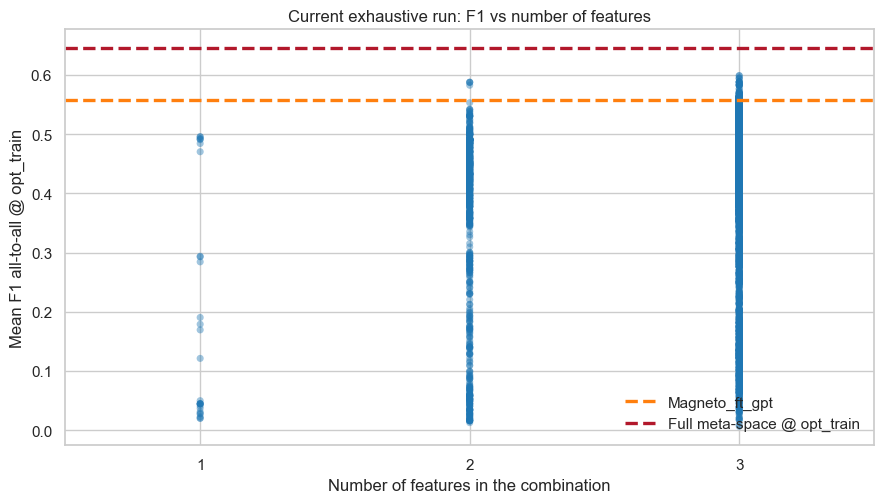

In [9]:

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.scatter(
    all_runs['n_features'],
    all_runs['mean_f1_all2all_opt_train'],
    s=26,
    alpha=0.42,
    color='#1f77b4',
    edgecolor='none',
)
ax.axhline(mag_row['metric_f1_at_05'], color='#ff7f0e', ls='--', lw=2.4, label='Magneto_ft_gpt')
ax.axhline(full_internal['mean_f1_all2all_opt_train'], color='#b2182b', ls='--', lw=2.4, label='Full meta-space @ opt_train')
ax.set_title('Current exhaustive run: F1 vs number of features')
ax.set_xlabel('Number of features in the combination')
ax.set_ylabel('Mean F1 all-to-all @ opt_train')
ax.set_xlim(0.5, all_runs['n_features'].max() + 0.5)
ax.set_xticks(sorted(all_runs['n_features'].unique()))
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.show()


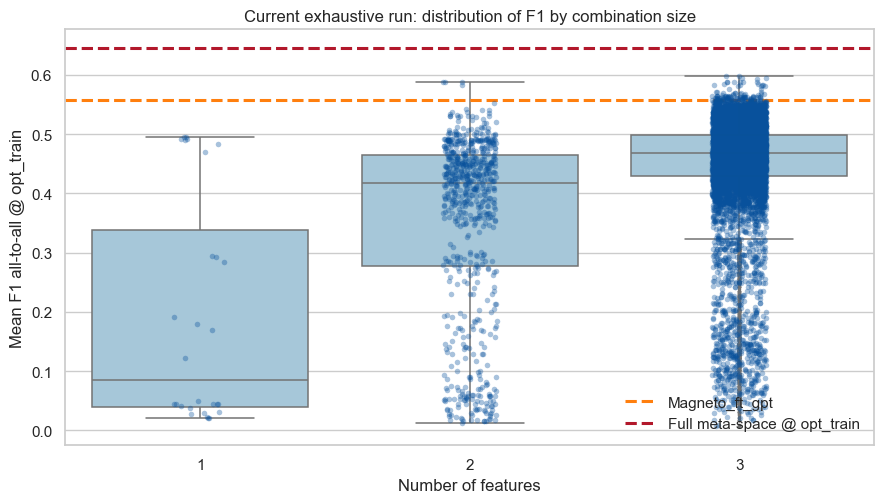

In [10]:

fig, ax = plt.subplots(figsize=(9, 5.2))
sns.boxplot(
    data=all_runs,
    x='n_features',
    y='mean_f1_all2all_opt_train',
    color='#9ecae1',
    fliersize=1.5,
    linewidth=1.1,
    ax=ax,
)
sns.stripplot(
    data=all_runs,
    x='n_features',
    y='mean_f1_all2all_opt_train',
    alpha=0.35,
    size=4,
    color='#08519c',
    ax=ax,
)
ax.axhline(mag_row['metric_f1_at_05'], color='#ff7f0e', ls='--', lw=2.2, label='Magneto_ft_gpt')
ax.axhline(full_internal['mean_f1_all2all_opt_train'], color='#b2182b', ls='--', lw=2.2, label='Full meta-space @ opt_train')
ax.set_title('Current exhaustive run: distribution of F1 by combination size')
ax.set_xlabel('Number of features')
ax.set_ylabel('Mean F1 all-to-all @ opt_train')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.show()



## 4. Meilleures configurations de la campagne actuelle


In [11]:

display(methods_summary)

cols = ['run_label','combo_id','n_features','mean_f1_all2all_opt_train','mean_f1_one2one','mean_delta_f1_all2all_vs_magneto','features']
display(all_runs.sort_values('mean_f1_all2all_opt_train', ascending=False)[cols].head(30))


,method_type,run_label,what_was_done,status_in_this_notebook
0,Exhaustive ablation on top-12 pool,xgb_ablation_top12_syn_cls_tda_no_overlap_parallel7,"All combinations from a fixed pool of 12 features, sizes 1..12, XGBoost evaluation.",Excluded from main analysis to avoid bias / repetition
1,Large exhaustive ablation (current main run),xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,Expanded pool of 40 non-overlap features; exhaustive combinations of size 1..3; top-12 combinations explicitly skipped; XGBoost evaluation.,Main analysis set
2,Forward stepwise without family constraint,xgb_forward_best,"Forward stepwise XGBoost selection over allowed features, overlap excluded, no requirement to keep all families.",Method summary only
3,Forward stepwise with family constraint,xgb_forward_fast,Forward stepwise XGBoost selection with required families syn+cls+tda and overlap excluded.,Method summary only
4,Small family-constrained smoke run,xgb_forward_require_families_smoke4,"Very small exploratory run constrained to exactly 3 features, one per family, mainly to probe feasibility.",Method summary only
5,Iterative minimal/full metaspace analysis,iterative_summary_by_k / chosen_minimal_feature_set,Comparison of different k values for the meta-space and search for a minimal set preserving full-model constraints.,Used as internal reference for full meta-space @ opt_train


,run_label,combo_id,n_features,mean_f1_all2all_opt_train,mean_f1_one2one,mean_delta_f1_all2all_vs_magneto,features
1627,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1805,3,0.598574,0.652202,0.040972,syn_jaro_winkler|syn_jaccard_tokens|syn_lcs_len
1683,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1862,3,0.598574,0.652202,0.040972,syn_jaro_winkler|syn_dice_tokens|syn_lcs_len
1646,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1824,3,0.594592,0.647635,0.036990,syn_jaro_winkler|syn_jaccard_tokens|tda_h0_count_src
1702,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1881,3,0.594592,0.647635,0.036990,syn_jaro_winkler|syn_dice_tokens|tda_h0_count_src
1442,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1585,3,0.593249,0.665348,0.035647,syn_jaro_winkler|syn_cosine_bigrams|syn_len_a
1474,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1625,3,0.588442,0.675630,0.030840,syn_jaro_winkler|syn_jaccard_trigrams|tda_h0_max_life_src
3979,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,4257,3,0.588152,0.611835,0.030550,syn_jaro|syn_jaccard_tokens|syn_lcs_len
4035,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,4314,3,0.588152,0.611835,0.030550,syn_jaro|syn_dice_tokens|syn_lcs_len
193,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,257,2,0.587638,0.612377,0.030036,syn_jaro|syn_contains_a_in_b
4435,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,4714,3,0.587638,0.611565,0.030036,syn_jaro|syn_contains_a_in_b|syn_equal_exact



## 5. Configurations qui battent `Magneto_ft_gpt`

Ici on regarde toutes les combinaisons de la campagne actuelle qui vérifient :
- `mean_f1_all2all_opt_train > Magneto_ft_gpt`


In [12]:

beat_mag = all_runs[all_runs['beats_magneto_global']].copy()
print('Number of combinations beating Magneto_ft_gpt globally:', len(beat_mag))

display(
    beat_mag.sort_values(['mean_f1_all2all_opt_train','mean_delta_f1_all2all_vs_magneto'], ascending=False)
            [['run_label','combo_id','n_features','mean_f1_all2all_opt_train','mean_delta_f1_all2all_vs_magneto','features']]
            .head(30)
)


Number of combinations beating Magneto_ft_gpt globally: 103


,run_label,combo_id,n_features,mean_f1_all2all_opt_train,mean_delta_f1_all2all_vs_magneto,features
1627,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1805,3,0.598574,0.040972,syn_jaro_winkler|syn_jaccard_tokens|syn_lcs_len
1683,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1862,3,0.598574,0.040972,syn_jaro_winkler|syn_dice_tokens|syn_lcs_len
1646,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1824,3,0.594592,0.036990,syn_jaro_winkler|syn_jaccard_tokens|tda_h0_count_src
1702,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1881,3,0.594592,0.036990,syn_jaro_winkler|syn_dice_tokens|tda_h0_count_src
1442,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1585,3,0.593249,0.035647,syn_jaro_winkler|syn_cosine_bigrams|syn_len_a
1474,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,1625,3,0.588442,0.030840,syn_jaro_winkler|syn_jaccard_trigrams|tda_h0_max_life_src
3979,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,4257,3,0.588152,0.030550,syn_jaro|syn_jaccard_tokens|syn_lcs_len
4035,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,4314,3,0.588152,0.030550,syn_jaro|syn_dice_tokens|syn_lcs_len
193,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,257,2,0.587638,0.030036,syn_jaro|syn_contains_a_in_b
4435,xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10,4714,3,0.587638,0.030036,syn_jaro|syn_contains_a_in_b|syn_equal_exact


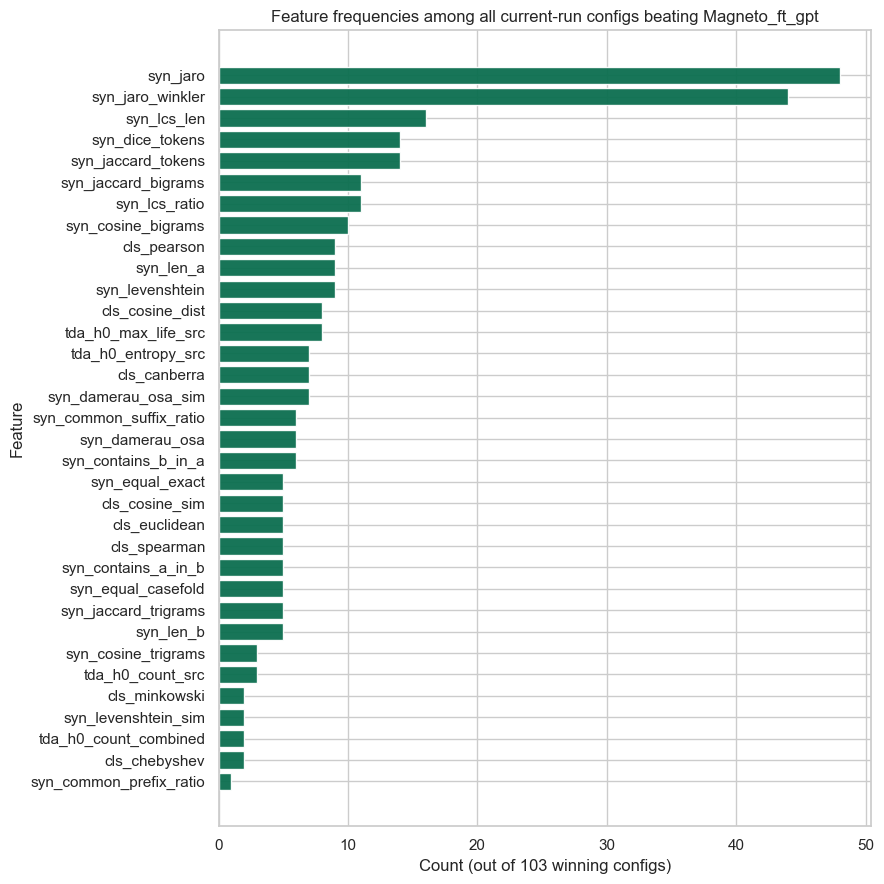

,feature,count,frequency
0,syn_jaro,48,0.466019
1,syn_jaro_winkler,44,0.427184
2,syn_lcs_len,16,0.155340
3,syn_dice_tokens,14,0.135922
4,syn_jaccard_tokens,14,0.135922
5,syn_jaccard_bigrams,11,0.106796
6,syn_lcs_ratio,11,0.106796
7,syn_cosine_bigrams,10,0.097087
8,cls_pearson,9,0.087379
9,syn_len_a,9,0.087379


In [13]:

feature_counts = Counter(f for feats in beat_mag['feature_list'] for f in feats)
freq_mag = pd.DataFrame({'feature': list(feature_counts.keys()), 'count': list(feature_counts.values())})
freq_mag['frequency'] = freq_mag['count'] / len(beat_mag)
freq_mag = freq_mag.sort_values(['count','feature'], ascending=[False, True]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 9))
plot_df = freq_mag.sort_values('count')
ax.barh(plot_df['feature'], plot_df['count'], color='#0b6e4f', alpha=0.95)
ax.set_title('Feature frequencies among all current-run configs beating Magneto_ft_gpt')
ax.set_xlabel(f'Count (out of {len(beat_mag)} winning configs)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

display(freq_mag)


In [14]:

display(
    beat_mag.sort_values(['mean_f1_all2all_opt_train','mean_delta_f1_all2all_vs_magneto'], ascending=False)
            [['combo_id','n_features','mean_f1_all2all_opt_train','mean_delta_f1_all2all_vs_magneto','mean_f1_one2one','features']]
)


,combo_id,n_features,mean_f1_all2all_opt_train,mean_delta_f1_all2all_vs_magneto,mean_f1_one2one,features
1627,1805,3,0.598574,0.040972,0.652202,syn_jaro_winkler|syn_jaccard_tokens|syn_lcs_len
1683,1862,3,0.598574,0.040972,0.652202,syn_jaro_winkler|syn_dice_tokens|syn_lcs_len
1646,1824,3,0.594592,0.036990,0.647635,syn_jaro_winkler|syn_jaccard_tokens|tda_h0_count_src
1702,1881,3,0.594592,0.036990,0.647635,syn_jaro_winkler|syn_dice_tokens|tda_h0_count_src
1442,1585,3,0.593249,0.035647,0.665348,syn_jaro_winkler|syn_cosine_bigrams|syn_len_a
...,...,...,...,...,...,...
2758,2986,3,0.558068,0.000466,0.650173,syn_jaccard_trigrams|syn_jaro|syn_len_a
4097,4377,3,0.558004,0.000402,0.642944,syn_jaro|cls_cosine_dist|syn_levenshtein
3323,3572,3,0.557813,0.000211,0.646095,syn_cosine_trigrams|syn_jaro|cls_cosine_sim
854,973,3,0.557800,0.000198,0.649694,syn_jaccard_bigrams|syn_jaro|cls_pearson



## 6. Le plus petit meta-space gagnant


In [15]:

smallest_vs_mag = (
    beat_mag.sort_values(['n_features','mean_f1_all2all_opt_train'], ascending=[True, False])
            [['combo_id','n_features','mean_f1_all2all_opt_train','mean_delta_f1_all2all_vs_magneto','features']]
)
display(smallest_vs_mag.head(30))

beat_full_internal = all_runs[all_runs['beats_full_internal_global']].copy()
print('Number of current-run combinations beating the full meta-space @ opt_train reference:', len(beat_full_internal))
if len(beat_full_internal):
    display(
        beat_full_internal.sort_values(['n_features','mean_f1_all2all_opt_train'], ascending=[True, False])
                          [['combo_id','n_features','mean_f1_all2all_opt_train','features']]
                          .head(30)
    )
else:
    display(Markdown('**No current-run combination beats the full meta-space @ opt_train reference on this global criterion.**'))


,combo_id,n_features,mean_f1_all2all_opt_train,mean_delta_f1_all2all_vs_magneto,features
193,257,2,0.587638,0.030036,syn_jaro|syn_contains_a_in_b
194,258,2,0.587300,0.029698,syn_jaro|syn_equal_exact
195,259,2,0.587300,0.029698,syn_jaro|syn_equal_casefold
192,256,2,0.582377,0.024775,syn_jaro|syn_contains_b_in_a
1627,1805,3,0.598574,0.040972,syn_jaro_winkler|syn_jaccard_tokens|syn_lcs_len
1683,1862,3,0.598574,0.040972,syn_jaro_winkler|syn_dice_tokens|syn_lcs_len
1646,1824,3,0.594592,0.036990,syn_jaro_winkler|syn_jaccard_tokens|tda_h0_count_src
1702,1881,3,0.594592,0.036990,syn_jaro_winkler|syn_dice_tokens|tda_h0_count_src
1442,1585,3,0.593249,0.035647,syn_jaro_winkler|syn_cosine_bigrams|syn_len_a
1474,1625,3,0.588442,0.030840,syn_jaro_winkler|syn_jaccard_trigrams|tda_h0_max_life_src


Number of current-run combinations beating the full meta-space @ opt_train reference: 0


**No current-run combination beats the full meta-space @ opt_train reference on this global criterion.**


## 7. Feature importance et contribution


In [16]:

if paths['feature_importance_mean_rank'].exists():
    fi_mean = pd.read_csv(paths['feature_importance_mean_rank'])
    display(fi_mean.head(30))

if paths['feature_importance_by_fold'].exists():
    fi_fold = pd.read_csv(paths['feature_importance_by_fold'])
    display(fi_fold.head(30))


,feature,importance_mean,rank
0,syn_jaccard_bigrams,0.100054,1
1,syn_jaro_winkler,0.089364,2
2,syn_cosine_bigrams,0.082567,3
3,syn_jaccard_trigrams,0.065318,4
4,syn_cosine_trigrams,0.060827,5
5,syn_jaro,0.058019,6
6,syn_lcs_ratio,0.049521,7
7,syn_damerau_osa_sim,0.041015,8
8,syn_levenshtein_sim,0.037257,9
9,syn_jaccard_tokens,0.022705,10


,feature,importance,fold_id
0,syn_len_a,4.610274e-03,0
1,syn_len_b,1.005220e-02,0
2,syn_equal_exact,0.000000e+00,0
3,syn_equal_casefold,0.000000e+00,0
4,syn_contains_a_in_b,0.000000e+00,0
5,syn_contains_b_in_a,4.086148e-17,0
6,syn_levenshtein,6.562337e-03,0
7,syn_levenshtein_sim,4.879838e-02,0
8,syn_damerau_osa,8.347722e-03,0
9,syn_damerau_osa_sim,5.700151e-02,0


,feature,family,mean_xgb_importance,median_xgb_importance,n_occurrences,n_combos
22,syn_jaro,syn,0.649122,0.605900,288,48
23,syn_jaro_winkler,syn,0.599678,0.616743,264,44
19,syn_jaccard_bigrams,syn,0.530381,0.550704,66,11
12,syn_cosine_bigrams,syn,0.467539,0.482207,60,10
21,syn_jaccard_trigrams,syn,0.358006,0.362650,30,5
25,syn_lcs_ratio,syn,0.343990,0.305955,66,11
13,syn_cosine_trigrams,syn,0.337914,0.341252,18,3
15,syn_damerau_osa_sim,syn,0.312608,0.312388,42,7
29,syn_levenshtein_sim,syn,0.300172,0.297027,12,2
16,syn_dice_tokens,syn,0.264588,0.258535,84,14


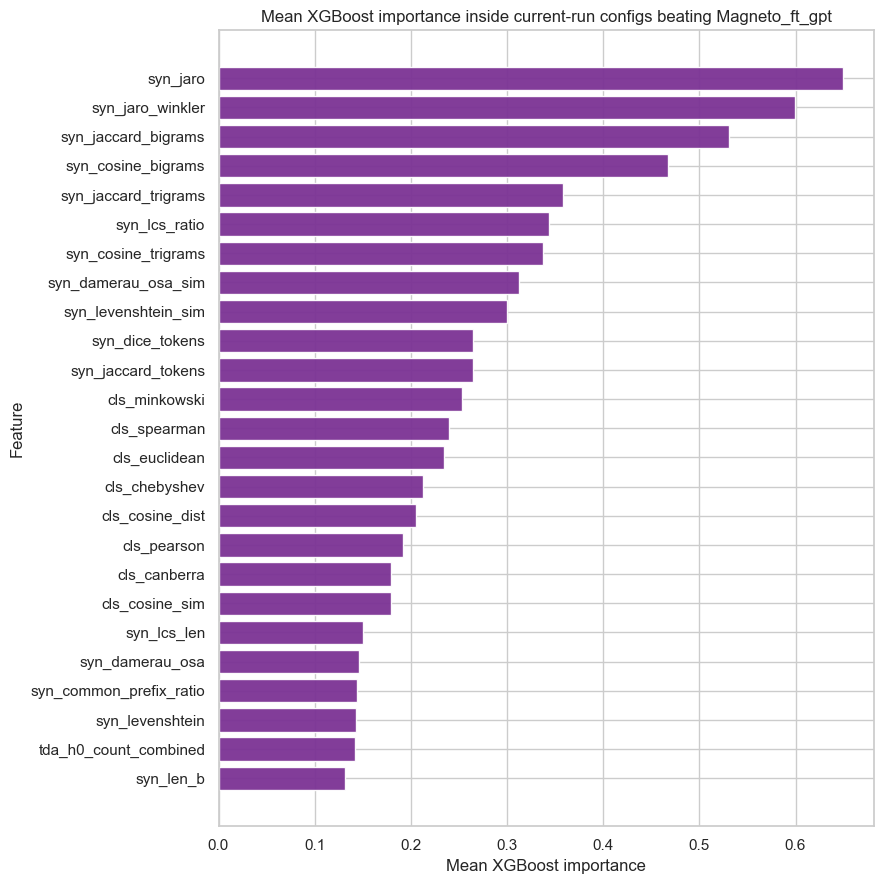

In [17]:

importance_frames = []
winning_combo_ids = set(beat_mag['combo_id'])
for p in sorted(FS.glob('**/combination_feature_importance.csv')):
    if p.parent.name != MAIN_RUN_LABEL:
        continue
    df = pd.read_csv(p)
    df = df[df['combo_id'].isin(winning_combo_ids)].copy()
    if not df.empty:
        importance_frames.append(df)

if importance_frames:
    imp = pd.concat(importance_frames, ignore_index=True)
    imp_summary = (imp.groupby(['feature','family'], as_index=False)
                     .agg(mean_xgb_importance=('xgb_importance','mean'),
                          median_xgb_importance=('xgb_importance','median'),
                          n_occurrences=('combo_id','count'),
                          n_combos=('combo_id','nunique'))
                     .sort_values(['mean_xgb_importance','n_combos'], ascending=False))
    display(imp_summary)

    fig, ax = plt.subplots(figsize=(9, 9))
    plot_df = imp_summary.sort_values('mean_xgb_importance').tail(25)
    ax.barh(plot_df['feature'], plot_df['mean_xgb_importance'], color='#7b3294', alpha=0.95)
    ax.set_title('Mean XGBoost importance inside current-run configs beating Magneto_ft_gpt')
    ax.set_xlabel('Mean XGBoost importance')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('No combination_feature_importance.csv available for the winning combinations of the current run.'))



## 8. Analyse sans la famille `syn_`

Ici on neutralise volontairement les features syntaxiques pour voir ce qui reste :
- uniquement `cls_`,
- uniquement `tda_`,
- ou mélange `cls_ + tda_`.

Cette section ne regarde que la campagne actuelle `~10000`.


In [18]:

no_syn = all_runs[~all_runs['has_syn']].copy()
print('Current-run configs without syn features:', len(no_syn))
print('Current-run configs without syn beating Magneto_ft_gpt:', (no_syn['mean_f1_all2all_opt_train'] > mag_row['metric_f1_at_05']).sum())

display(
    no_syn.sort_values(['mean_f1_all2all_opt_train','mean_delta_f1_all2all_vs_magneto'], ascending=False)
          [['combo_id','n_features','family_signature','mean_f1_all2all_opt_train','mean_delta_f1_all2all_vs_magneto','features']]
          .head(30)
)


Current-run configs without syn features: 930
Current-run configs without syn beating Magneto_ft_gpt: 0


,combo_id,n_features,family_signature,mean_f1_all2all_opt_train,mean_delta_f1_all2all_vs_magneto,features
6472,6771,3,cls,0.503861,-0.053741,cls_minkowski|cls_euclidean|cls_cosine_sim
6377,6675,3,cls,0.500948,-0.056654,cls_minkowski|cls_pearson|cls_spearman
6399,6699,3,cls,0.500466,-0.057136,cls_minkowski|cls_cosine_dist|cls_cosine_sim
6496,6795,3,cls,0.500078,-0.057524,cls_minkowski|cls_cosine_sim|cls_spearman
366,446,2,cls,0.499745,-0.057857,cls_pearson|cls_euclidean
364,443,2,cls,0.499598,-0.058004,cls_pearson|cls_cosine_dist
394,473,2,cls,0.499567,-0.058035,cls_cosine_dist|cls_cosine_sim
368,447,2,cls,0.499442,-0.058160,cls_pearson|cls_cosine_sim
466,545,2,cls,0.499359,-0.058243,cls_euclidean|cls_cosine_sim
312,391,2,cls,0.499066,-0.058536,cls_minkowski|cls_euclidean


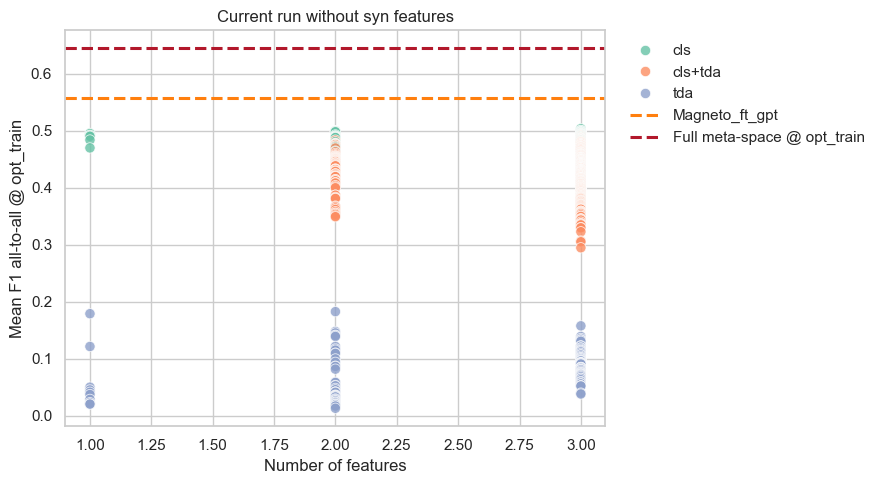

,feature,count
0,cls_canberra,154
1,cls_chebyshev,154
2,cls_cosine_dist,154
3,cls_cosine_sim,154
4,cls_euclidean,154
5,cls_pearson,154
6,cls_spearman,154
7,tda_h0_entropy_combined,154
8,tda_h0_wasserstein,154
9,cls_minkowski,153


In [19]:

if len(no_syn):
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.scatterplot(
        data=no_syn,
        x='n_features',
        y='mean_f1_all2all_opt_train',
        hue='family_signature',
        palette='Set2',
        alpha=0.8,
        s=55,
        ax=ax,
    )
    ax.axhline(mag_row['metric_f1_at_05'], color='#ff7f0e', ls='--', lw=2.2, label='Magneto_ft_gpt')
    ax.axhline(full_internal['mean_f1_all2all_opt_train'], color='#b2182b', ls='--', lw=2.2, label='Full meta-space @ opt_train')
    ax.set_title('Current run without syn features')
    ax.set_xlabel('Number of features')
    ax.set_ylabel('Mean F1 all-to-all @ opt_train')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()

    feature_counts_no_syn = Counter(f for feats in no_syn['feature_list'] for f in feats)
    freq_no_syn = pd.DataFrame({'feature': list(feature_counts_no_syn.keys()), 'count': list(feature_counts_no_syn.values())})
    freq_no_syn = freq_no_syn.sort_values(['count','feature'], ascending=[False, True]).reset_index(drop=True)
    display(freq_no_syn)
else:
    display(Markdown('No non-syn configurations found in the current run.'))



## 9. Vue pair-level

Cette partie reste informative, mais elle n'est **pas** la vue principale du notebook.

Point important :
- les exports pair-level actuels n'incluent pas `Magneto_ft_gpt` ;
- donc la comparaison pair-level directe contre cette variante n'est pas possible ici ;
- la partie centrale du notebook repose donc volontairement sur les métriques globales de la campagne actuelle.


In [20]:

# What is actually available at pair level?
pair_methods = sorted(pair_all['method'].unique())
print('Pair-level methods available:', pair_methods)
print('Unique pair_id:', pair_all['pair_id'].nunique())
print('Unique (fold_id, pair_id):', pair_all[['fold_id','pair_id']].drop_duplicates().shape[0])

BUILD_PAIRWISE_FULL_CACHE = False
PAIRWISE_FULL_CACHE_PATH = NB_OUT / 'combo_vs_full_meta_space_foldpair_summary_latest.csv'

def build_pairwise_summary_vs_full(run_dirs=None):
    ref = pair_all[pair_all['method'] == 'meta_space'][['fold_id','pair_id','metric_f1_all2all']].rename(
        columns={'metric_f1_all2all': 'full_f1_all2all'}
    )
    run_dirs = run_dirs or sorted(FS.glob('**/combination_pair_metrics.csv'))
    parts = []
    for p in run_dirs:
        run_label = p.parent.name
        chunk_parts = []
        for chunk in pd.read_csv(p, usecols=['combo_id','n_features','features','fold_id','pair_id','f1_all2all_opt_train'], chunksize=200000):
            merged = chunk.merge(ref, on=['fold_id','pair_id'], how='inner')
            if merged.empty:
                continue
            merged['win_vs_full'] = (merged['f1_all2all_opt_train'] > merged['full_f1_all2all']).astype(int)
            merged['tie_vs_full'] = (merged['f1_all2all_opt_train'] == merged['full_f1_all2all']).astype(int)
            merged['delta_vs_full'] = merged['f1_all2all_opt_train'] - merged['full_f1_all2all']
            grp = merged.groupby(['combo_id','n_features','features'], as_index=False).agg(
                n_compared=('pair_id','size'),
                f1_sum=('f1_all2all_opt_train','sum'),
                wins_vs_full=('win_vs_full','sum'),
                ties_vs_full=('tie_vs_full','sum'),
                delta_sum_vs_full=('delta_vs_full','sum'),
            )
            chunk_parts.append(grp)
        if not chunk_parts:
            continue
        part = pd.concat(chunk_parts, ignore_index=True)
        part = part.groupby(['combo_id','n_features','features'], as_index=False).sum()
        part['run_label'] = run_label
        parts.append(part)
    if not parts:
        return pd.DataFrame()
    summary = pd.concat(parts, ignore_index=True)
    summary['mean_f1_all2all_opt_train'] = summary['f1_sum'] / summary['n_compared']
    summary['mean_delta_vs_full'] = summary['delta_sum_vs_full'] / summary['n_compared']
    summary['losses_vs_full'] = summary['n_compared'] - summary['wins_vs_full'] - summary['ties_vs_full']
    summary['winrate_vs_full_half_ties'] = (summary['wins_vs_full'] + 0.5 * summary['ties_vs_full']) / summary['n_compared']
    summary = summary.drop(columns=['f1_sum','delta_sum_vs_full'])
    return summary

if PAIRWISE_FULL_CACHE_PATH.exists():
    pairwise_full = pd.read_csv(PAIRWISE_FULL_CACHE_PATH)
    display(pairwise_full.head())
elif BUILD_PAIRWISE_FULL_CACHE:
    pairwise_full = build_pairwise_summary_vs_full()
    if not pairwise_full.empty:
        pairwise_full.to_csv(PAIRWISE_FULL_CACHE_PATH, index=False)
        display(pairwise_full.head())
    else:
        display(Markdown('No pairwise-full cache could be built from the currently available files.'))
else:
    display(Markdown('Pair-level cache vs full meta-space not built yet. Set `BUILD_PAIRWISE_FULL_CACHE = True` if you want to compute it.'))


Pair-level methods available: ['ISResMat', 'LLMATCH', 'Magneto_ft_no_gpt', 'Magneto_no_ft_no_gpt', 'coma', 'coma_inst', 'coma_instance', 'coma_pp', 'coma_schema', 'cupid', 'cupid_ext', 'distribution_based', 'distribution_based_ext', 'meta_space', 'similarity_flooding', 'similarity_flooding_ext']
Unique pair_id: 447
Unique (fold_id, pair_id): 830


Pair-level cache vs full meta-space not built yet. Set `BUILD_PAIRWISE_FULL_CACHE = True` if you want to compute it.

In [21]:

if 'pairwise_full' in globals() and isinstance(pairwise_full, pd.DataFrame) and not pairwise_full.empty:
    print('Combos with pair-level winrate > 0.5 vs full meta_space:', (pairwise_full['winrate_vs_full_half_ties'] > 0.5).sum())
    display(
        pairwise_full.sort_values(['n_features','winrate_vs_full_half_ties','mean_delta_vs_full'], ascending=[True, False, False])
                    [['run_label','combo_id','n_features','n_compared','winrate_vs_full_half_ties','mean_delta_vs_full','features']]
                    .head(20)
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.scatterplot(
        data=pairwise_full,
        x='n_features', y='winrate_vs_full_half_ties', hue='run_label',
        alpha=0.18, s=18, ax=ax
    )
    ax.axhline(0.5, color='tab:red', ls='--')
    ax.set_title('Pair-level winrate vs full meta_space')
    ax.set_xlabel('Number of features')
    ax.set_ylabel('Winrate (half ties)')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('The notebook currently has no pair-level cache vs `meta_space` loaded.'))


The notebook currently has no pair-level cache vs `meta_space` loaded.


## 10. Takeaways

Ce notebook est maintenant centré sur **une seule campagne d'analyse principale** :
- `xgb_ablation_syn_cls_tda_h0_wasserstein_only_no_overlap_max3_parallel10`

On a volontairement exclu :
- la campagne `top12 / 4095`,
- toute feature contenant `overlap`,
- toute fusion qui risquait de réintroduire des répétitions entre campagnes.

Sections à lire en priorité :
- **Quelles méthodes ont été faites ?** pour comprendre le protocole,
- **Meilleures configurations**,
- **Plus petit meta-space gagnant**,
- **Feature frequencies / importance**,
- **Analyse sans `syn_`**.
